In [1]:
import warnings                   # neglect unnessasary warnings 
import numpy as np                #FOR LINEAR ALGEBRA OPERATIONS
import pandas as pd               #DATA PROCESSING AND ACCESS LIKE CSV FILES 
import matplotlib.pyplot as plt   #TO PLOT THE DATA 
import seaborn as sns             #TO REPRESENT THE PLOTS
from sklearn.impute import SimpleImputer   #REPLACE THE MISSING VALUES WITH CENTRAL TENDENDIES LIKE MEAN MEDIAN AND MORE
from scipy.stats import boxcox             #TO NORMALIZE THE DATA
from scipy.special import inv_boxcox       #REVERSE THE DATA THAT IS TO GET THE DTA INTO ORIGINAL STATE WHICH IS PRESENT IN FINALSTAGE TO MAKE USER UNDERSTANDABLE
from sklearn.base import BaseEstimator, TransformerMixin                       #INTEGRATION OF CUSTOME TRANSFORMERS WITH THE EXISTING SCILIT-LEARNING COMPONENTS
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder  #FOR DATA PREPROCESSING
from sklearn.pipeline import Pipeline                                          #PASS COMMANDS IN A ORDER

import os                                             #INPUT DATA FILES ARE AVAILABEL IN THE READ-ONLY"../INPUT/" DIRECTORY
for dirname, _,filenames in os.walk("/kaggle/input"): #THIS EXAMPLE WOULD ITERATE THROUGH ALL THE FILES IN /KAGGLE/INPUT/DATA DIRECTORY
    for filename in filenames:                        #AND ITS SUBDIRECTORIES, AND PRINT THE PATH OF ANY CSV FILE FOUND
        print(os.path.join(dirname,filename))         #YOU COULD THEN ADD CODE TO PROCESS THESE CSV FILES AS NEEDED

warnings.filterwarnings('ignore')   #COMMAND WHEN A WARNING OCCURS

# 1.DATA ANALYSING

In [2]:
df_dir = r"C:\Users\LOLLA SRIKANTH\Desktop\New folder (2)\2\i.MIN-BE 350\2024\intern\4.customerChurn\archive\Churn_Modelling.csv"
df = pd.read_csv(df_dir)

In [3]:
print("Training data shape:", df.shape)

Training data shape: (10000, 14)


In [4]:
print("Dataset info:")
print(df.info())
print("--"*20)
print("First Few Rows:")
df.head()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
----------------------------------------
First Few Rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


##### ANALYSING DATA ACCORDING TO DAT TYPE DISTRIBUTION

###### 1.vISUALIZING DATA OF CATEGORICAL DISTRIBUTIONS

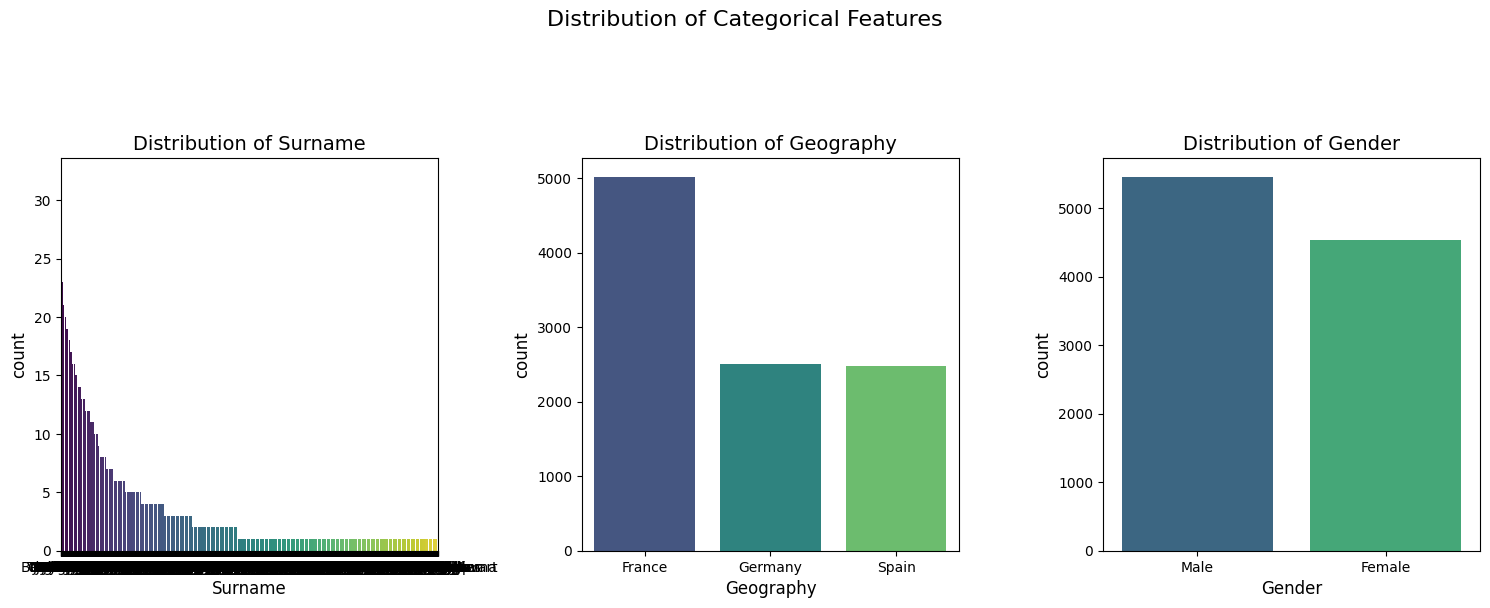

In [6]:
def visualize_categorical_distributions(df):
    categorical_columns = df.select_dtypes(include=['object']).columns
    num_cols = 3
    num_rows = (len(categorical_columns)+ num_cols -1) 
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15,num_rows* 5))
    fig.suptitle("Distribution of Categorical Features", fontsize=16)

    axes = axes.flatten()

    for i,col in enumerate(categorical_columns):
        sns.barplot(
            x=df[col].value_counts().index,
            y=df[col].value_counts().values,
            ax=axes[i],
            palette = 'viridis'
        )
        axes[i].set_title(f"Distribution of {col}", fontsize=14)
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel("count", fontsize=12)
        axes[i].tick_params(axis='x')

    for j in range(i +1,len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0,0.03,1,0.95])
    plt.show()
visualize_categorical_distributions(df)


##### 2.Visualizing data of numerical distributions

In [7]:
def visualize_numerical_distributions(df, exclude_columns=['RowNumber', 'CustomerId', "Exited"]):
    
    if exclude_columns is None:                                            #ENSURE THAT exclude_columns is a LIST
        exclude_columns = []                                               #WILL MAKE ENTRY IF THISIS EMPTY SET SO CODE WILL NOT BREAK

    numerical_columns = df.select_dtypes(include=['number']).columns       #IDENTIFY NUMERICAL COLUMNS AND EXCLUDE ONES IN THIS exclude_columns SET
    numerical_columns = [col for col in numerical_columns if col not in exclude_columns]

    #REPRESENTATION OF THE NUMERICAL DATA
    num_cols = 3                                                    # Number of columns for the subplot grid
    num_rows = (len(numerical_columns) + num_cols - 1) // num_cols  # Calculate number of rows needed

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 5 * num_rows))
    fig.suptitle('Distribution of Numerical Features', fontsize=16)

    axes = axes.flatten()                                            #FLAT THE AXES FROM 3D,2D INTO LINEAR SO CAN EASILY ITERATED

    #ITERATING THROUGH EACH NUMERICAL TYPE COLUMN AND CREATE HISTOGRAM WITH KDE
    for i, col in enumerate(numerical_columns):
        sns.histplot(df[col], kde=True, ax=axes[i], color="skyblue", element="step", stat="density")
        axes[i].set_title(f'Distribution of {col}', fontsize=14)         #NAMING THE HISTOGRAM AND PROVIDING THE FONT SIZE
        axes[i].set_xlabel(col, fontsize=12)                             #ASSIGNING THE X-AXIS
        axes[i].set_ylabel('Density', fontsize=12)                       #ASSIGNING THE Y-AXIS

    #REMOVING UNUSED AXES (WHEN REPRESENTED HAVING CATEGORICAL COLUMNS AND FEW AXIS SLOTS ARE LEFT )
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust the main title space
    plt.show()                                 # REPRESENTATION OF THE NUMERICAL DATA PLOT



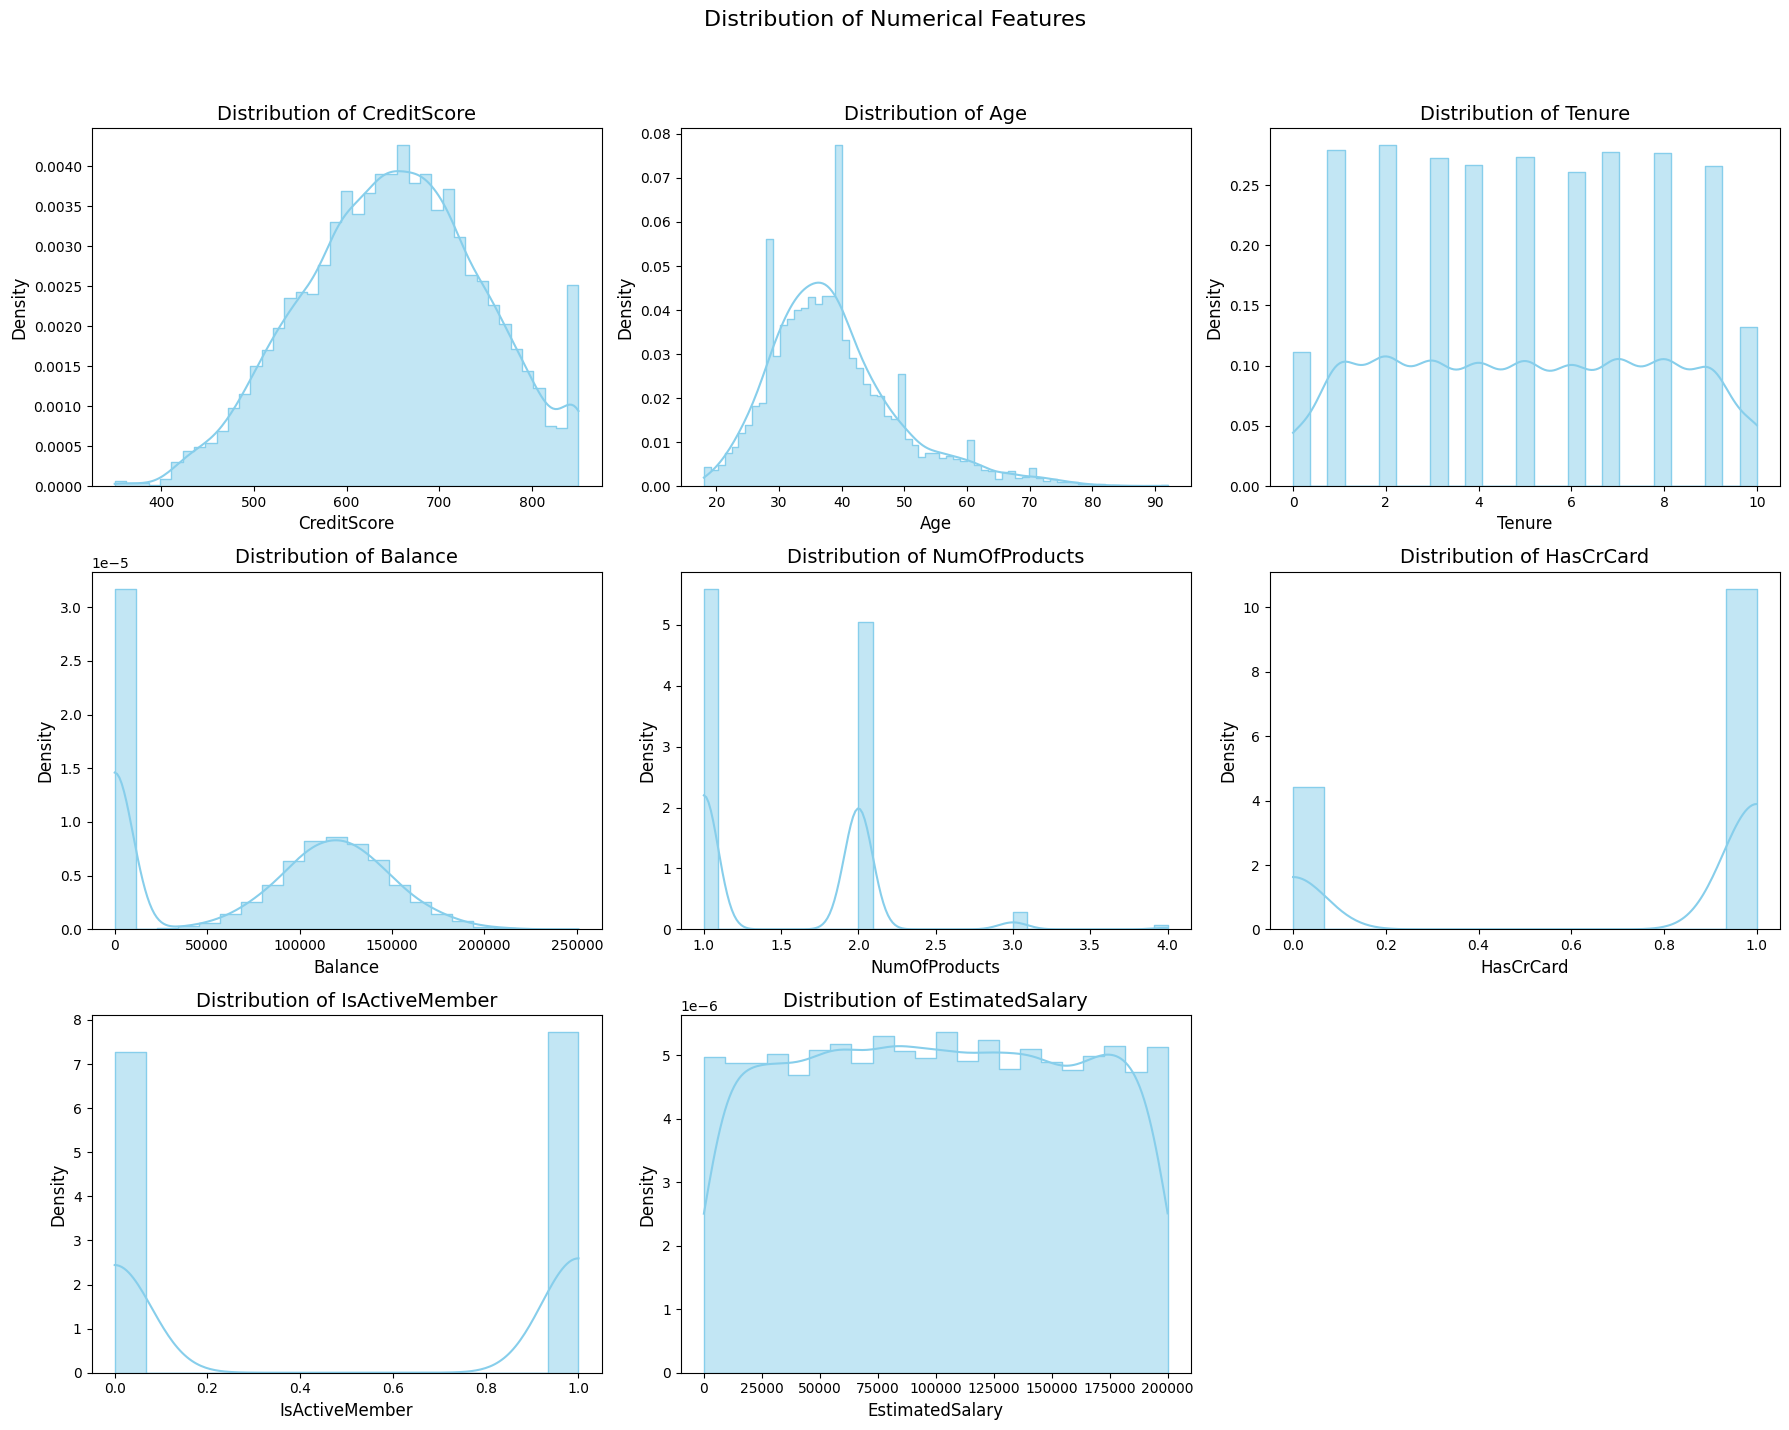

In [8]:
visualize_numerical_distributions(df)

# 2.DATA PREPROCESSING:: Converting Categorical to Numerical data :::      By FeatureOneHotEncoder, Label Encoder, Dropper


#### Converting Categorical to Numerical Data

In [9]:
class FeatureEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):                    #FOR KNOWING ESTIMATOR'S PARAMETER FOR THE TRAINING DATA
        return self                               

    def transform(self, X):                                        #ENCODING CATEGORICAL VALUES TO NUMERICAL REPRESENTATION ::: HERE TO 'SPARSE MATRIX'
        encoder = OneHotEncoder()
        matrix = encoder.fit_transform(X[['Geography']]).toarray() #CONVERTING MATRIX TO NUMPY ARRAY 
        column_names = ['France', 'Germany', 'Spain']              #CREATE CORRESPONDING COLUMN NAMES

        for i in range(len(matrix.T)):          #ASSIGN VALUES FOR COLUMNS ACC TO MATRIX TAKEN
            X[column_names[i]]= matrix.T[i]

        return X

In [10]:
class FeatureLabel(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):                    #FOR KNOWING ESTIMATOR'S PARAMETER FOR THE TRAINING DATA
        return self 

    def transform(self, X):                                    #ENCODING CATEGORICAL VALUES TO NUMERICAL REPRESENTATION ::: HERE TO 'SPARSE MATRIX'
        label_encoder = LabelEncoder()

        X['Gender'] = label_encoder.fit_transform(X['Gender']) #ASSIGNING NUMERICALS TO EACH GENDER MALE WITH '0' AND FEMALE ASSIGNED '1'
        return X

In [19]:
class FeatureDropper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):                    #FOR KNOWING ESTIMATOR'S PARAMETER FOR THE TRAINING DATA
        return self

    def transform(self, X):                      #DROPPING THESE COLUMNS AXIS=1 MEANS TO DO THE TASK, IGNORE IF ANY OF THESE COLUMNS NOT THERE
        return X.drop(['RowNumber', 'CustomerId', 'Surname', 'Geography'],axis=1, errors='ignore')

##### Creating a Pipeline

In [22]:
#THIS IS APPLYING THE FEATURES IN A ORDER ACCORDING TO THE PIPELINE
pipeline = Pipeline([
    ('feature_encoder',FeatureEncoder()),
    ('feature_label', FeatureLabel()),
    ('feature_dropper', FeatureDropper())
])
train_data = pipeline.fit_transform(df)

In [23]:
train_data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany,Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


##### FINDING THE CORRELATION BTW LABLE AND COLUMNS IN THE DATAFRAME ie, DATA

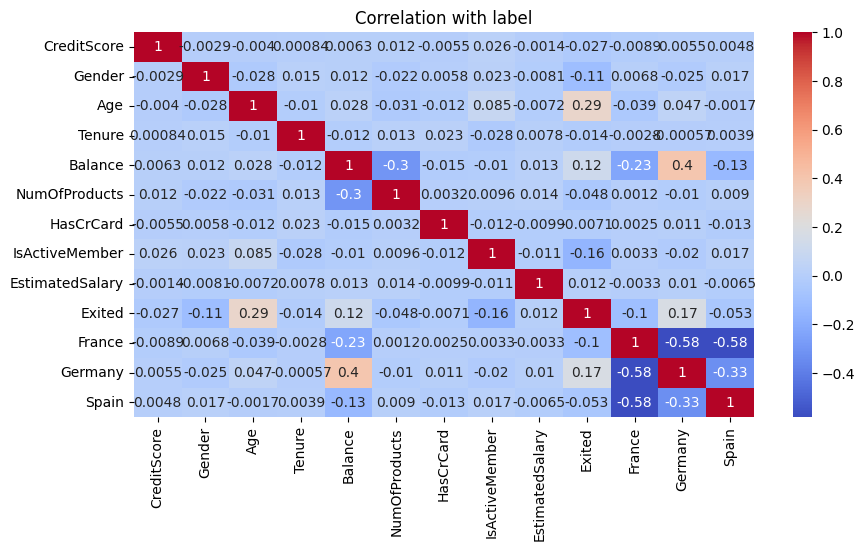

In [26]:
corr_train_data = train_data.corr()

plt.figure(figsize=(10,5))                                     #REPRESENTATION PLOT SIZE
sns.heatmap(data=corr_train_data, annot=True, cmap='coolwarm') #SPECIFING DATA FOR RUNNING, ALLOWING TO RUN, COLOR
plt.title("Correlation with label")                            #NAME FOR THE REPRESENTATION
plt.show()                                                     #SHOWING THE PLOT

# 3.SPLITTING DATA TO TRAIN AND TEST DATA

In [30]:
x = train_data.drop("Exited", axis=1)     #CREATE FEATURE AND LABEL
y= train_data['Exited']

In [31]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)  #SPLIT DATA 80% TO TRAIN AND 20% TEST DATA

# 4.Model Building 

##### Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression

model_1 = LogisticRegression()    #DATA IS GIVEN A NAME
model_1.fit(x_train, y_train)     #FITTING TRAIN DATA AND TRAINING MODEL

pred_1 = model_1.predict(x_test)  #TESTING DATA 

##### BernoullisNB Model

In [34]:
from sklearn.naive_bayes import BernoulliNB
model_2 = BernoulliNB()
model_2.fit(x_train, y_train)
pred_2 = model_2.predict(x_test)

##### Random Forest Classifier Model

In [35]:
from sklearn.ensemble import RandomForestClassifier

model_3 = RandomForestClassifier()
model_3.fit(x_train, y_train)

pred_3 = model_3.predict(x_test)

##### Gradient Booster Classifier Model

In [36]:
from xgboost import XGBClassifier

model_4 = XGBClassifier()
model_4.fit(x_train,y_train)

pred_4 = model_4.predict(x_test)

### Evaluation of the Model

In [39]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Evaluating the Model::")
print("--"*10)

print("Logistic Regression Model AC:", accuracy_score(y_test, pred_1))
print(confusion_matrix(y_test, pred_1))

print("BernoulliNB Model AC:", accuracy_score(y_test, pred_2))
print(confusion_matrix(y_test, pred_2))

print("RandomForestClassifier Model AC:", accuracy_score(y_test, pred_3))
print(confusion_matrix(y_test, pred_1))

print("XGBClassifier Model AC:", accuracy_score(y_test, pred_4))
print(confusion_matrix(y_test, pred_4))

Evaluating the Model::
--------------------
Logistic Regression Model AC: 0.8
[[1569   38]
 [ 362   31]]
BernoulliNB Model AC: 0.8
[[1537   70]
 [ 330   63]]
RandomForestClassifier Model AC: 0.865
[[1569   38]
 [ 362   31]]
XGBClassifier Model AC: 0.8625
[[1523   84]
 [ 191  202]]


#### Save the Model

In [40]:
import pickle
model_name = "b_c_churn_model.pkl"

with open(model_name, 'wb') as file:
    pickle.dump(model_3, file)

x_test.to_csv('predicted.csv', index=False)